In [744]:
import torch
import json
from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.data import Data
from torch_geometric.utils import negative_sampling
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
import plotly.express as px
import pandas as pd
import os
from scipy.stats import pearsonr

import src.config as cfg
import statsmodels.api as sm
import seaborn as sns


In [745]:
FEATURES = [
    ("weights", "WoS Categories"),
    ("weights", "Document Types"),
    ("weights", "Documents,"),
    ("scores",  "Ave. citations"),
    ("scores",  "Ave. authorships"),
    ("scores",  "Ave. references"),
    ("scores",  "Percent of documents"),
    ("scores",  "Percent of documents Int. Coll.")
]
def json_to_pyg_data(json_data, scaler=None):
    items = json_data["network"]["items"]
    links = json_data["network"]["links"]

    id_map = {node["id"]: i for i, node in enumerate(items)}

    node_features = []
    for node in items:
        features = [
            node["weights"].get("WoS Categories", 0),
            node["weights"].get("Document Types",  0),
            node["weights"].get("Documents,", 0),
            node["scores"].get("Ave. citations",0.0),
            node["scores"].get("Ave. authorships",0.0),
            node["scores"].get("Ave. references",0.0),
         node["scores"].get("Percent of documents",0.0),
            node["scores"].get("Percent of documents Int. Coll.",0.0)
        ]
        node_features.append(features)
    
    #x = torch.tensor(node_features, dtype=torch.float)
    features_array = np.array(node_features, dtype=float)

    if scaler is None:
        scaler = StandardScaler().fit(features_array)
    features_scaled = scaler.transform(features_array)

    x = torch.tensor(features_scaled, dtype=torch.float)

    #Aristas
    sources = []
    targets = []
    edge_weights = []
    
    for link in links:
        u_str = link["source_id"]
        v_str = link["target_id"]
        strength = link["strength"]

        u = id_map[u_str]
        v = id_map[v_str]

        sources.append(u)
        targets.append(v)
        edge_weights.append(strength)


    edge_index = torch.tensor([sources, targets], dtype = torch.long)
    edge_attr = torch.tensor(edge_weights, dtype=torch.float).view(-1,1) #al ser de una sola dimensión, lo pasamos a una matriz de x filas por 1 columna


    #El tipo "Data" es exclusivamente para que sage pueda procesar el grafo
    data = Data(x=x, edge_index = edge_index, edge_attr = edge_attr)
    #x son mis caracteristicas
    #edge_index es la topologia (aristas)
    #edge_attr en este caso son únicamente los pesos

    return data


In [746]:
def fit_global_scaler(data_folder, start_year, end_year, feature_keys, exclude_ego=True):
    """
    feature_keys: lista de tuplas (scope, key) como FEATURES
    """
    all_rows = []

    for year in range(start_year, end_year + 1):
        file_path = os.path.join(data_folder, f"network_{year}.json")
        if not os.path.exists(file_path):
            continue

        with open(file_path, "r") as f:
            raw_json = json.load(f)

        items = raw_json["network"]["items"]

        for node in items:
            if exclude_ego and (str(node.get("id","")).startswith("MCT")):
                continue

            row = []
            for scope, key in feature_keys:
                row.append(node.get(scope, {}).get(key, 0))
            all_rows.append(row)

    all_rows = np.asarray(all_rows, dtype=float)
    scaler = StandardScaler()
    scaler.fit(all_rows)
    return scaler

In [747]:
with open("./Data/BN/network_2003.json", "r") as f:
    raw_json = json.load(f)

snapshot_2003 = json_to_pyg_data(raw_json)
print(f"Snapshot creado: {snapshot_2003}")
print(f"Nodos: {snapshot_2003.num_nodes}, Features: {snapshot_2003.num_node_features}")

Snapshot creado: Data(x=[397, 8], edge_index=[2, 396], edge_attr=[396, 1])
Nodos: 397, Features: 8


In [748]:
data = snapshot_2003
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)
data = data.to(device)

Usando dispositivo: cuda


In [749]:
class GraphSAGEEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.relu = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(p=0.1)

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x  # embeddings finales

In [750]:
in_channels = data.num_node_features   # En nuestro caso son 8 features
hidden_channels = 32
out_channels = 8   # dimensión del embedding final

model = GraphSAGEEncoder(in_channels, hidden_channels, out_channels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.BCEWithLogitsLoss()

In [751]:

def get_link_logits(z, edge_index):
    # z: [N, d]
    src, dst = edge_index
    # producto punto entre embeddings de los extremos
    # Si dos vectores apuntan a la misma direccion (son similares) entonces tendrán un valor positivo, en caso contrario
    return (z[src] * z[dst]).sum(dim=-1)  # [num_edges]

def train_linkpred(model, data, epochs=200):
    model.train()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        z = model(data.x, data.edge_index)
        # aristas  positivas (reales)
        pos_edge_index = data.edge_index
        # aristas negativas
        neg_edge_index = negative_sampling(
            edge_index=pos_edge_index,
            num_nodes=data.num_nodes,
            num_neg_samples=pos_edge_index.size(1),  # mismo número que positivas
            method="sparse"
        )
        # Logits para positivas y negativas
        pos_logits = get_link_logits(z, pos_edge_index)
        neg_logits = get_link_logits(z, neg_edge_index)
        logits = torch.cat([pos_logits, neg_logits], dim=0)
        labels = torch.cat([
            torch.ones(pos_logits.size(0), device=device),
            torch.zeros(neg_logits.size(0), device=device)
        ], dim=0)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")
    return model

In [752]:
trained_model = train_linkpred(model, data, epochs=200)
trained_model.eval()
with torch.no_grad():
    z = trained_model(data.x, data.edge_index)  # [num_nodes, out_channels]

embeddings = z.cpu().numpy()
print("dimension de embeddings:", embeddings.shape)  # (num_nodes, out_channels)
print(embeddings[0])

items = raw_json["network"]["items"]
clusters = [node.get("cluster", -1) for node in items]  # lista de clusters


Epoch 001 | Loss: 0.5316
Epoch 020 | Loss: 0.3915
Epoch 040 | Loss: 0.3630
Epoch 060 | Loss: 0.3754
Epoch 080 | Loss: 0.3612
Epoch 100 | Loss: 0.3735
Epoch 120 | Loss: 0.3745
Epoch 140 | Loss: 0.3854
Epoch 160 | Loss: 0.3576
Epoch 180 | Loss: 0.3586
Epoch 200 | Loss: 0.3714
dimension de embeddings: (397, 8)
[-2.8093269e+01 -3.9942522e+00 -6.2387874e-03 -1.6297638e+01
  1.3766100e+01 -2.2211491e+01  1.3550239e+01  2.9122093e+01]


In [753]:
def get_ego_mask(raw_json):
    """
    Devuelve un tensor booleano:
    True  -> nodo ALTER
    False -> nodo EGO (MCT)
    """
    mask = []
    for node in raw_json["network"]["items"]:
        is_ego = (
            node["id"].startswith("MCT") or
            node["scores"].get("Percent of documents", 0) == 100.0
        )
        mask.append(not is_ego)
    return torch.tensor(mask, dtype=torch.bool)


In [754]:

# z ya existe, NO usamos z_nodes aquí
ego_mask = get_ego_mask(raw_json).to(device)

# Filtrar solo alters
z_alters = z[ego_mask]

# Nuevo batch: todos los alters pertenecen al mismo grafo
batch_alters = torch.zeros(z_alters.size(0), dtype=torch.long, device=device)

graph_embedding = global_mean_pool(z_alters, batch_alters)

print("Dimension del embedding del grafo (sin ego):", graph_embedding.shape)
print(graph_embedding)


# Crear el vector batch (todos los nodos tienen la etiqueta 0 porque es un solo grafo)
# z es la matriz de embeddings de todos los nodos, es de la forma [No.Nodos, out_channels]
print(z.shape)
#batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)

# Hacemos el pooling usando los embeddings de nodos ya entrenados (z)
# El pooling hace un "promedio" en base al tamaño del batch, en nuestro caso
# al poner batch como un tensor llenos de 0's, entonces promedia todos aquellos que tengan como indice 0 (todos los nodos)
#Devuelve una matriz de [1, 16], "comprime" todos los embeddings a uno solo
#graph_embedding = global_mean_pool(z, batch)
print("Dimension del embedding del grafo:", graph_embedding.shape)
print(graph_embedding)

Dimension del embedding del grafo (sin ego): torch.Size([1, 8])
tensor([[-0.0613, -0.0129,  0.0036, -0.0287,  0.0304, -0.0502,  0.0320,  0.0593]],
       device='cuda:0')
torch.Size([397, 8])
Dimension del embedding del grafo: torch.Size([1, 8])
tensor([[-0.0613, -0.0129,  0.0036, -0.0287,  0.0304, -0.0502,  0.0320,  0.0593]],
       device='cuda:0')


In [755]:
PRESERVAR_HISTORIA = True
START_YEAR = 1980
END_YEAR = 2024
DATA_FOLDER = "./Data/SOM"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


if PRESERVAR_HISTORIA:
    model = GraphSAGEEncoder(in_channels, hidden_channels, out_channels).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    print("Modo: con memoria")
else:
    print("Modo: Sin memoria")
# lilsta de eembeddings de cada año
historia = []
global_scaler = fit_global_scaler(DATA_FOLDER, START_YEAR, END_YEAR, FEATURES, exclude_ego=True)

for year in range(START_YEAR, END_YEAR + 1):
    file_path = os.path.join(DATA_FOLDER, f"network_{year}.json")
    
    # Verificar si el archivo existe 
    # El de 1990 no está en la plataforma del c3
    if not os.path.exists(file_path):
        print(f"Saltando {year}: Archivo no encontrado.")
        continue
        
    try:
        with open(file_path, "r") as f:
            raw_json = json.load(f)
        
        data = json_to_pyg_data(raw_json, scaler=global_scaler)
        data = data.to(device)

        if not PRESERVAR_HISTORIA:
            model = GraphSAGEEncoder(in_channels, hidden_channels, out_channels).to(device) #reseteamos al modelo anterior y creamos uno nuevo
            optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4) #renovar el optimizador para el nuevo modelo

        
        # Entrenar el modelo con el año actual
        # No se pierde la información del año anterior si no se reseteo el modelo
        model = train_linkpred(model, data, epochs=60) 
        
        #Embeddings de Nodos
        model.eval()
        with torch.no_grad():
            z_nodes = model(data.x, data.edge_index)
            
            # pooling para hacer un solo embedding de un snapshot
            batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)
            graph_embedding = global_mean_pool(z_nodes, batch) # Shape: [1, 16]
            
            # Guardar el resultado
            historia.append({
                "year": year,
                "vector": graph_embedding.cpu().numpy()[0] # Convertir a array plano
            })
            
        print(f"{year} procesado.")
        
    except Exception as e:
        print(f"Error en {year}: {e}")

print(f"Se generaron {len(historia)} puntos.")

Modo: con memoria
Epoch 001 | Loss: 0.6121
Epoch 020 | Loss: 0.4879
Epoch 040 | Loss: 0.4166
Epoch 060 | Loss: 0.4671
1980 procesado.
Epoch 001 | Loss: 0.4961
Epoch 020 | Loss: 0.4387
Epoch 040 | Loss: 0.4203
Epoch 060 | Loss: 0.4217
1981 procesado.
Epoch 001 | Loss: 0.4379
Epoch 020 | Loss: 0.3940
Epoch 040 | Loss: 0.4754
Epoch 060 | Loss: 0.4767
1982 procesado.
Epoch 001 | Loss: 0.4376
Epoch 020 | Loss: 0.4128
Epoch 040 | Loss: 0.4101
Epoch 060 | Loss: 0.4589
1983 procesado.
Epoch 001 | Loss: 0.4021
Epoch 020 | Loss: 0.4014
Epoch 040 | Loss: 0.3897
Epoch 060 | Loss: 0.4746
1984 procesado.
Epoch 001 | Loss: 0.4318
Epoch 020 | Loss: 0.4299
Epoch 040 | Loss: 0.4242
Epoch 060 | Loss: 0.4104
1985 procesado.
Epoch 001 | Loss: 1.1938
Epoch 020 | Loss: 0.4617
Epoch 040 | Loss: 0.3837
Epoch 060 | Loss: 0.4714
1986 procesado.
Epoch 001 | Loss: 0.4164
Epoch 020 | Loss: 0.4069
Epoch 040 | Loss: 0.3783
Epoch 060 | Loss: 0.3758
1987 procesado.
Epoch 001 | Loss: 0.3605
Epoch 020 | Loss: 0.3789
Epoc

In [756]:
print(graph_embedding.shape)

torch.Size([1, 8])


In [757]:

vectores = np.array([item["vector"] for item in historia]) #array que contiene los vectores de cada año
years = [item["year"] for item in historia] #para reetiquetar los puntos de acuerdo a su año

# Reducir a 2D
pca = PCA(n_components=2) #Aplanar las 16 mensiones de cada embedding (out_channels=16) a unicamente 2 (coordenadas x,y)
pca_result = pca.fit_transform(vectores) #hacemos uso del algoritmo de pca

# DataFrame para poder graficarlo por medio de Plotly
df_trayectoria = pd.DataFrame({
    'x': pca_result[:, 0], #Todas las filas, pero solo la columna 0, es decir, el eje x
    'y': pca_result[:, 1], #Todas las filas, pero solo la columna 1, es decir, el eje y
    'year': years,
    'label': [str(y) for y in years] 
})

#Graficar la Trayectoria
fig = px.scatter(df_trayectoria, x='x', y='y', 
                 text='label', 
                 color='year',
                 title="Evolución")

# líneas para conectar los puntos
fig.update_traces(mode='lines+markers+text', textposition='top center')

fig.show()

In [758]:


vectores = np.array([item["vector"] for item in historia])
years = [item["year"] for item in historia]

pca_1d = PCA(n_components=1)
coord_y_original = pca_1d.fit_transform(vectores).flatten()

df_flujo = pd.DataFrame({
    'year': years,
    'y_original': coord_y_original
})

# Grafico de linea
fig = px.line(
    df_flujo, 
    x='year', 
    y='y_original',
    title="Evolucion",
    labels={'y_original': 'PC1', 'year': 'Año'},
    markers=True, # ñuntos de cada año
    template="plotly_white"
)

#fig.update_traces(line_shape='spline', line_width=4) #esto es unicamente para "suavizar las esquinas"
fig.show()




In [759]:
# Guardar serie PC1 de GraphSAGE por año
out_dir = "./Output"
os.makedirs(out_dir, exist_ok=True)
df_sage = df_flujo.rename(columns={"y_original": "sage_pc1"}).copy()

out_path = os.path.join(out_dir, "graphsage_pca1.csv")
df_sage.to_csv(out_path, index=False, encoding="utf-8")
print(f"[OK] Guardado: {out_path}")


[OK] Guardado: ./Output/graphsage_pca1.csv


Promedios anuales
PC1 ya estaba alineado con 'Percent of documents'. Corr: 0.9201

Resultados de Correlación con el Eje Y PC1
WoS Categories: 0.2245
Document Types: 0.1467
Documents,: 0.4671
Ave. citations: 0.2169
Ave. authorships: -0.5263
Ave. references: 0.1833
Percent of documents: 0.9201
Percent of documents Int. Coll.: -0.1900


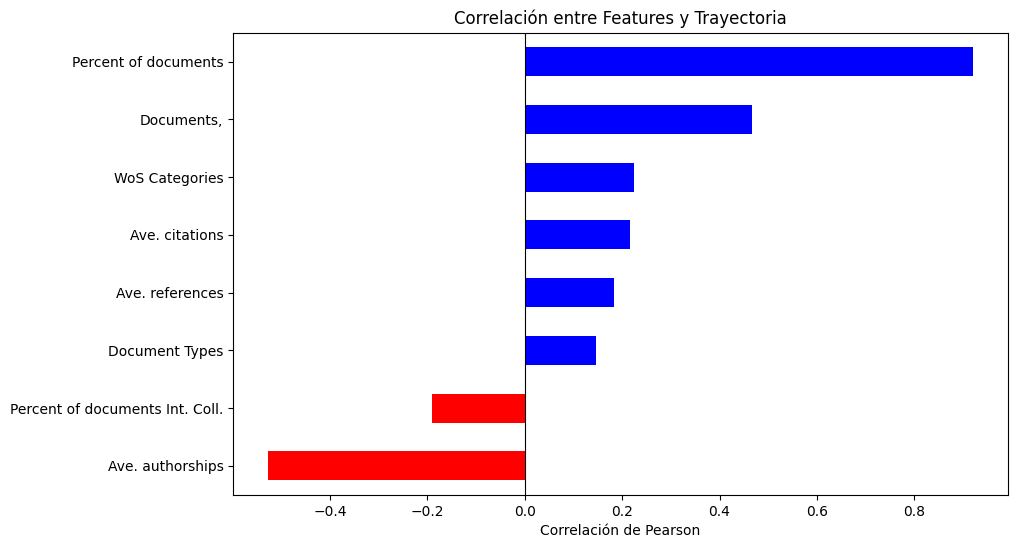

In [760]:
# Correlación de pearson dice qué tan fuerte es la relación lineal entre dos variables
# Cuando la variable A sube, ¿ldf_flujoa variable B también sube proporcionalmente?
#trayectoria_y = df_flujo['y_original'].values
years = df_flujo['year'].values

feature_names = [
    "WoS Categories", "Document Types", "Documents,", 
    "Ave. citations", "Ave. authorships", "Ave. references", 
    "Percent of documents", "Percent of documents Int. Coll."
]

# Matriz para guardar el promedio de cada feature por año
# Tamaño: [num_años, num_features]
features_anuales = []

print("Promedios anuales")
#¿Por qué es necesario hacer un promedio?
#Para poder ocupar la correlacion de pearson, debemos de comparar los 45 puntos resultantes del pca con otros 45 puntos.
#(La comparación es 1 a 1 por cada feature, es decir, fijamos un feature y lo comparamos con los 45 tiempos)
#Sin embargo, cada año tiene cierta cantidad de nodos, es necesario obtener un solo valor a partir de todos estos.
#por eso se realiza un promedio

#Para cada año (cada json definido en la carpeta Data_Json)
#Para cada feature (feature_names)
#Añadimos el valor de ese feature de cada nodo a la lista "vals"
#al finalizar de contabilizar este feature, realizamos un promedio y lo agregamos a feats_year
#continuamos con el siguiente feature, continuamos cn el siguiente año hasta terminar
for year in years:
    with open(f"./Data/SOM/network_{year}.json", "r") as f:
        raw_json = json.load(f)

    items = raw_json["network"]["items"]
    feats_year = []
    for feature in feature_names:
        # Extraer el valor de cada nodo
        vals = []
        for node in items:
            val = node.get("weights", {}).get(feature) or node.get("scores", {}).get(feature, 0)
            vals.append(val)
        # Guardar el promedio de este año
        feats_year.append(np.mean(vals))
    
    features_anuales.append(feats_year) #cada fila es un año, y 8 columnas, cada una es el promedio de toda la grafica de un solo feature

df_features = pd.DataFrame(features_anuales, columns=feature_names, index=years)


#Ya tenemos los datos como queremos, podemos proceder a realizar correlacion
#Lista A (Trayectoria generada por pca): 45 valores.
#Lista B (Promedio de cada feature): 45 valores.

# Simplementa para que PCA1 sea consistente multiplico por -1 en caso de que percent of documents sea negativo
# a pca no le importa  si es negativo o positivo
particular_col = "Percent of documents"

r_particular, _ = pearsonr(df_flujo["y_original"].values, df_features[particular_col].values)

if r_particular < 0:
    df_flujo["y_original"] = -df_flujo["y_original"]
    trayectoria_y = df_flujo["y_original"].values
    print(f"Se invirtió el signo de PC1 para alinearlo con '{particular_col}'. Corr original: {r_particular:.4f}")
else:
    trayectoria_y = df_flujo["y_original"].values
    print(f"PC1 ya estaba alineado con '{particular_col}'. Corr: {r_particular:.4f}")

correlaciones = {}

print("\nResultados de Correlación con el Eje Y PC1")
for col in df_features.columns:
    r, p_value = pearsonr(trayectoria_y, df_features[col].values) #aqui ya están los 45 años y 45 promedios de cada feature
    correlaciones[col] = r
    print(f"{col}: {r:.4f}")

# Con los valores basta, pero para tener una mejor visualización:
plt.figure(figsize=(10, 6))
sorted_corr = pd.Series(correlaciones).sort_values()# los más importantes primero
colors = ['red' if x < 0 else 'blue' for x in sorted_corr]
sorted_corr.plot(kind='barh', color=colors)
plt.title("Correlación entre Features y Trayectoria")
plt.xlabel("Correlación de Pearson")
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

In [761]:
print(df_features)

      WoS Categories  Document Types  Documents,  Ave. citations  \
1980        4.592593        1.666667    5.814815       25.018519   
1981        3.687500        1.500000    5.296875       26.009219   
1982        4.779661        1.525424    6.593220       86.254407   
1983        4.138889        1.444444    5.750000       47.642222   
1984        3.739130        1.500000    5.413043       38.248913   
1985        4.294118        1.529412    7.264706       29.074706   
1986        5.578947        1.526316   11.684211       23.662632   
1987        5.435540        1.843206    8.094077       41.162613   
1988        4.596899        1.627907    4.689922       39.926279   
1989        3.741935        1.435484    4.790323       20.731452   
1990        4.523256        1.546512    4.883721       41.865000   
1991        5.428571        1.816327    8.408163       26.337388   
1992        5.284444        1.715556    7.280000       30.240400   
1993        4.115385        1.576923    5.923077

In [762]:
#Percent of documents resultó  tener una correlación bastante alta, por lo tanto, las gráficas
#deberían ser bastante parecidas (la generada por pca y la que es a partir de los datos crudos)
#"Ave. authorships"
atributo_a_graficar = "Percent of documents"
#datos que calculamos en el paso anterior (df_features)
df_plot = df_features.reset_index().rename(columns={'index': 'Year'})
fig = px.line(
    df_plot, 
    x='Year', 
    y=atributo_a_graficar,
    title=f"Evolución de: {atributo_a_graficar}",
    markers=True,
    template="plotly_white"
)

# esto es solo para suavisar las esquinas
#fig.update_traces(line_shape='spline', line_width=3)
fig.show()

In [763]:
# 'inner' para quedarnos solo con los años que existen en ambos lados
df_comparacion = pd.merge(df_plot, df_flujo, left_on='Year', right_on='year', how='inner')

# Normalización Manual (Escala 0 a 1)
# Para poder comparar directamente las tendencias
#PD es percent of documents

#Por cada atributo definido, se busca al maximo, y a cada valor (fila) es dividido entre ese valor
df_comparacion['PD Crudos'] = df_comparacion['Percent of documents'] / df_comparacion['Percent of documents'].max()
df_comparacion['PD PCA'] = df_comparacion['y_original'] / df_comparacion['y_original'].max()
df_comparacion['Autores'] = df_comparacion['Ave. authorships'] / df_comparacion['Ave. authorships'].max()
# Graficar
fig = px.line(
    df_comparacion, 
    x='Year', 
    y=['PD Crudos', 'PD PCA', 'Autores'], 
    title="Comparación de evoluciónes de los embeddings contra los datos crudos",
    labels={'value': 'Intensidad Relativa (0-1)', 'variable': 'Curva', 'Year': 'Año'},
    template="plotly_white",
    markers=False
)

fig.update_traces(line=dict(width=3)) 
fig.update_traces(patch={"line": {"dash": "dot"}}, selector={"name": "Autores"})
fig.update_traces(patch={"line": {"dash": "dot"}}, selector={"name": "PD Crudos"})
fig.show()

In [764]:


df_stage2 = pd.read_csv(f"./Output/metricas_{cfg.LEVEL}.csv")
df_sage = pd.read_csv("./Output/graphsage_pca1.csv")

#aqui unimos los 2 data frames
df_all = pd.merge(df_stage2, df_sage, on="year", how="inner").sort_values("year").reset_index(drop=True)

# Target: lo que queremos explicar
y = df_all["sage_pc1"].astype(float).to_numpy()

# Candidatas predictoras, hay mas pero de momento estos
candidate_cols = [
    "mean_Percent of documents",
    "mean_Ave. authorships",
    "mean_Ave. citations",
    "mean_Ave. references",
    "hill_q1",
    "hill_q2",
    "top1_share",
    "trace_cov",
    "mean_dist_to_mu",
]

X_cols = [c for c in candidate_cols if c in df_all.columns]
print("Features usadas:", X_cols)

X = df_all[X_cols].astype(float)



Features usadas: ['mean_Percent of documents', 'mean_Ave. authorships', 'mean_Ave. citations', 'mean_Ave. references', 'hill_q1', 'hill_q2', 'top1_share', 'trace_cov', 'mean_dist_to_mu']


In [765]:


y = df_all['sage_pc1'] 
X = df_all[['mean_Percent of documents', 'mean_Ave. authorships']]

# Le ponemos su constante 
#Ecuacion lineal de la forma y=b0 + b1x1 + b2x2 donde los xn son los atributos
X = sm.add_constant(X) #cada atributo definido en X es un valor asociado a x_n, b0 es la constante (lo definimos como 1), b1 y b2 son los valores a estimar
modelo = sm.OLS(y, X).fit(cov_type='HC3') #Entrenamiento que no asume homocedasticidad (no asumimos que los errores tienen varianza constante)
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     46.40
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           2.32e-11
Time:                        22:58:58   Log-Likelihood:                 68.605
No. Observations:                  45   AIC:                            -131.2
Df Residuals:                      42   BIC:                            -125.8
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [766]:
columnas_validas = [c for c in candidate_cols if c in df_all.columns]
X_todas = df_all[columnas_validas]
X_todas = sm.add_constant(X_todas)

# modelo lineal múltiple
modelo_completo = sm.OLS(y, X_todas).fit()
print(modelo_completo.summary())



                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.908
Method:                 Least Squares   F-statistic:                     49.17
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           3.14e-17
Time:                        22:58:58   Log-Likelihood:                 87.574
No. Observations:                  45   AIC:                            -155.1
Df Residuals:                      35   BIC:                            -137.1
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [ ]:
# Gráfica de dispersión con línea de regresión OLS
fig = px.scatter(
    df_all, 
    x='mean_Percent of documents', 
    y='sage_pc1',
    hover_data=['year'],
    title="Impacto del Porcentaje de Documentos en GraphSAGE PC1",
    labels={
        'mean_Percent of documents': 'Porcentaje de Documentos (Promedio Anual)',
        'sage_pc1': 'Componente Principal 1 (GraphSAGE)'
    },
    trendline='ols', # dibuja la recta automáticamente
    trendline_color_override='red',
    template="plotly_white"
)

# Para ver los puntos un poco más grandes y transparentes
fig.update_traces(marker=dict(size=10, opacity=0.7))

fig.show()

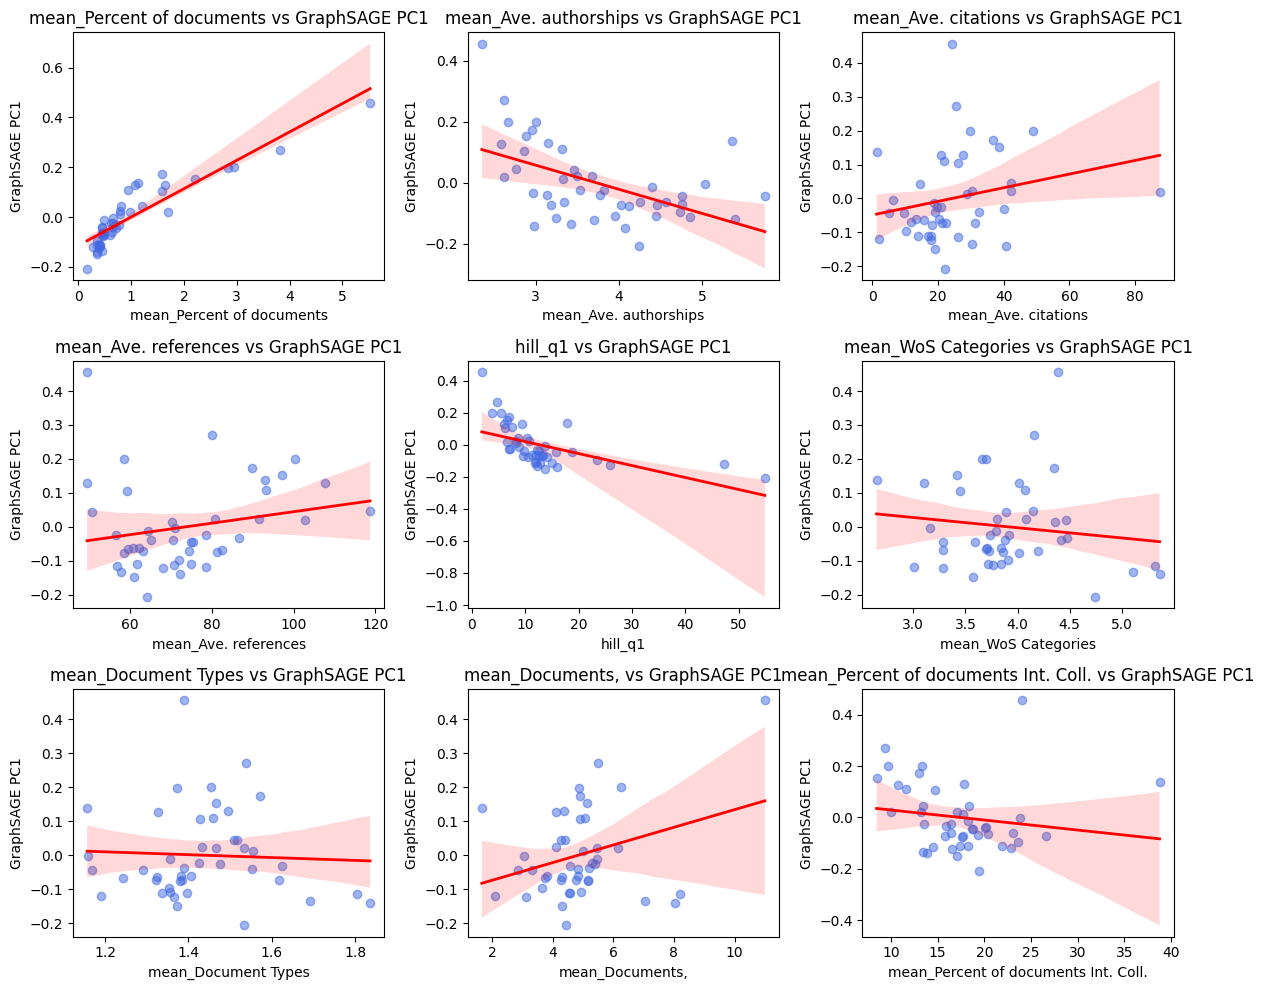

In [768]:


# features que van a pelear contra GraphSAGE
features_a_topar = [
    'mean_Percent of documents', 
    'mean_Ave. authorships', 
    'mean_Ave. citations', 
    'mean_Ave. references',
    'hill_q1',
    "mean_WoS Categories", 
    "mean_Document Types", 
    "mean_Documents,", 
    'mean_Percent of documents Int. Coll.'

]


# matriz de 3x3. figsize es el tamaño de la imagen
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(features_a_topar):
    # sns.regplot dibuja los puntos ya la linea automaticamente
    sns.regplot(
        data=df_all, 
        x=feature, 
        y='sage_pc1', 
        ax=axes[i],
        scatter_kws={'alpha': 0.5, 'color': 'royalblue'}, #puntos
        line_kws={'color': 'red', 'linewidth': 2} #linea
    )
    axes[i].set_title(f"{feature} vs GraphSAGE PC1")
    axes[i].set_ylabel('GraphSAGE PC1')

# para que las gráficas no se encimen
plt.tight_layout()
plt.show()